# MCP Approach: Single-Agent Workflow Demo (Condition C)

This notebook demonstrates the MCP (Model Context Protocol) approach to automated
scientific workflow reproduction, single-agent variant. One agent reads a paper, plans
the work, installs the stack, and executes everything via an MCP server tool-calling
loop — all within one continuous, growing conversation. There is no orchestrator and
no separate agents to route between; see `maw_evaluation_plan.md` for why (this repo
implements Condition C of that ablation).

## Architecture

```
single_agent:
  planning   (no tools; reads PDF -> literature_findings, stack_decision, tasks)
     ↓
  install    (no tools, no LLM call; deterministic pip install from stack_decision)
     ↓
  execution  (tools unlock here; executes tasks via MCP server tool calls)
     ↓
    END
```

## 1. Setup & Configuration

In [3]:
import os, json, sys
from datetime import datetime
from IPython.display import display, HTML, Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Set project root
PROJECT_ROOT = os.path.dirname(os.path.abspath('.'))
if os.path.exists('agent_mcp.py'):
    PROJECT_ROOT = os.getcwd()
os.chdir(PROJECT_ROOT)
print(f"Project root: {PROJECT_ROOT}")
print(f"Available papers:")
for i, f in enumerate(sorted(os.listdir('Literature')), 1):
    if f.endswith('.pdf'):
        print(f"  {i}. {f}")

Project root: /Users/xuejunchen/Documents/GitHub/MCP_Approach
Available papers:
  1. 3624062.3624151 2.pdf
  2. 3624062.3624151.pdf
  3. DeepDriveMD_Deep-Learning_Driven_Adaptive_Molecular_Simulations_for_Protein_Folding 2.pdf
  4. DeepDriveMD_Deep-Learning_Driven_Adaptive_Molecular_Simulations_for_Protein_Folding.pdf
  5. YildizO_RAPIDS.pdf
  6. cise-article-YILDIZ.pdf
  7. yildiz-isvfcs22-chapter.pdf


## 2. LangGraph Flow Diagram

The agent graph structure:

In [4]:
from agent_mcp import app

# Print Mermaid diagram
mermaid_code = app.get_graph().draw_mermaid()
print(mermaid_code)

# Try to render as PNG
try:
    png_data = app.get_graph().draw_mermaid_png()
    with open('workflow_graph.png', 'wb') as f:
        f.write(png_data)
    display(Image('workflow_graph.png'))
except Exception as e:
    print(f"(Could not render PNG: {e})")
    print("Paste the Mermaid code above into https://mermaid.live to see the diagram.")

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	orchestrator(orchestrator)
	planner(planner)
	installer(installer)
	explorer(explorer)
	__end__([<p>__end__</p>]):::last
	__start__ --> orchestrator;
	explorer --> orchestrator;
	installer --> orchestrator;
	orchestrator -. &nbsp;end&nbsp; .-> __end__;
	orchestrator -.-> explorer;
	orchestrator -.-> installer;
	orchestrator -.-> planner;
	planner --> orchestrator;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

(Could not render PNG: Failed to reach https://mermaid.ink API while trying to render your graph after 1 retries. To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

## 3. Run the Workflow

Select a paper and engine, then run the full pipeline.
The trace logger records every agent interaction.

In [5]:
# Configuration
PAPER_INDEX = 2           # Change this to select a paper
ENGINE = "parsl"          # "parsl" or "pycompss"
GOAL = "Reproduce the scientific workflow described in this paper"

print(f"Paper: {PAPER_INDEX}")
print(f"Engine: {ENGINE}")
print(f"Goal: {GOAL}")

Paper: 2
Engine: parsl
Goal: Reproduce the scientific workflow described in this paper


In [6]:
# Run the workflow (this may take several minutes)
import subprocess, sys

env = {**os.environ, "VENV_PYTHON": os.path.join(PROJECT_ROOT, ".venv/bin/python")}

result = subprocess.run(
    [sys.executable, "agent_mcp.py",
     "--paper", str(PAPER_INDEX),
     "--engine", ENGINE,
     "--goal", GOAL],
    capture_output=True, text=True, env=env,
    timeout=3600,
)

print("Exit code:", result.returncode)
if result.returncode != 0:
    print("STDERR:", result.stderr[-2000:])

Exit code: 1
STDERR: /chat_models/base.py", line 1667, in _generate
    _handle_openai_api_error(e)
    ~~~~~~~~~~~~~~~~~~~~~~~~^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/langchain_openai/chat_models/base.py", line 1662, in _generate
    raw_response = self.client.with_raw_response.create(**payload)
  File "/opt/anaconda3/lib/python3.13/site-packages/openai/_legacy_response.py", line 367, in wrapped
    return cast(LegacyAPIResponse[R], func(*args, **kwargs))
                                      ~~~~^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/openai/_utils/_utils.py", line 298, in wrapper
    return func(*args, **kwargs)
  File "/opt/anaconda3/lib/python3.13/site-packages/openai/resources/chat/completions/completions.py", line 1251, in create
    return self._post(
           ~~~~~~~~~~^
        "/chat/completions",
        ^^^^^^^^^^^^^^^^^^^^
    ...<52 lines>...
        stream_cls=Stream[ChatCompletionChunk],
        ^^^^^^^^^^^^^^^^^^^^^^^^^^

## 4. Load and Visualize the Trace

The trace logger saved a JSON file with every agent interaction.

In [ ]:
# Choose which trace to visualize.
#   PICK = ""  -> use the latest trace in runs/
#   PICK = "runs/20260617_145111_trace.json"  -> use that specific trace
PICK = "runs/20260617_145111_trace.json"

if PICK:
    trace_path = PICK
else:
    trace_files = sorted(f for f in os.listdir('runs') if f.endswith('_trace.json'))
    trace_path = os.path.join('runs', trace_files[-1]) if trace_files else None

if trace_path and os.path.isfile(trace_path):
    print(f"Loading trace: {trace_path}")
    with open(trace_path) as f:
        trace_data = json.load(f)

    engine_used = next(
        (e.get("metadata", {}).get("engine")
         for e in trace_data["trace"]
         if e["type"] == "agent_start" and e["agent"] == "single_agent"),
        "unknown",
    )
    print(f"\nSummary:")
    print(f"  Engine: {engine_used}")
    summary = trace_data['summary']
    print(f"  Agents: {', '.join(summary['agents_involved'])}")
    print(f"  Tool calls: {summary['tool_calls']} ({summary['tool_successes']} succeeded)")
    print(f"  Duration: {summary['total_duration_s']}s")
else:
    print("No trace found. Set PICK to a runs/*_trace.json path, or run the workflow first (Cell 3).")
    trace_data = None

## 5. Agent Interaction Timeline

Visualize how agents interact over time.

In [ ]:
if trace_data:
    events = trace_data['trace']
    
    # Color map -- one agent now, kept as a dict for symmetry with the waterfall cell below
    agent_colors = {
        'single_agent': '#4A90D9',
    }
    
    # Build timeline data
    timeline = []
    for event in events:
        if event['type'] == 'agent_start':
            timeline.append({
                'agent': event['agent'],
                'start': event['elapsed_s'],
                'end': None,
            })
        elif event['type'] == 'agent_end':
            for t in reversed(timeline):
                if t['agent'] == event['agent'] and t['end'] is None:
                    t['end'] = event['elapsed_s']
                    break
    
    # Fill missing ends
    max_time = max(e['elapsed_s'] for e in events)
    for t in timeline:
        if t['end'] is None:
            t['end'] = max_time
    
    # Plot timeline
    fig, ax = plt.subplots(figsize=(14, 4))
    agents_list = list(agent_colors.keys())
    
    for t in timeline:
        if t['agent'] in agents_list:
            y = agents_list.index(t['agent'])
            ax.barh(y, t['end'] - t['start'], left=t['start'],
                    color=agent_colors[t['agent']], alpha=0.8, height=0.6)
    
    ax.set_yticks(range(len(agents_list)))
    ax.set_yticklabels(agents_list, fontsize=12)
    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_title('Agent Execution Timeline', fontsize=14)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('agent_timeline.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: agent_timeline.png")

## 6. Interaction Log

Show the sequence of phase inputs/outputs and tool calls within the run.

In [38]:
if trace_data:
    events = trace_data['trace']
    
    print("=" * 80)
    print("AGENT INTERACTION LOG")
    print("=" * 80)
    
    for event in events:
        t = event.get('elapsed_s', 0)
        
        if event['type'] == 'routing':
            print(f"\n[{t:>7.1f}s] {event['from']} ──→ {event['to']}")
            if event.get('reasoning'):
                # Show first sentence of reasoning
                reason = event['reasoning'].split('.')[0] + '.'
                print(f"           Reason: {reason}")
            if event.get('feedback'):
                print(f"           Feedback: {event['feedback'][:100]}")
        
        elif event['type'] == 'agent_input':
            data = event.get('data', {})
            items = ', '.join(f"{k}={v}" for k, v in data.items())
            print(f"[{t:>7.1f}s]   INPUT:  {items[:120]}")
        
        elif event['type'] == 'agent_output':
            data = event.get('data', {})
            items = ', '.join(f"{k}={v}" for k, v in data.items())
            print(f"[{t:>7.1f}s]   OUTPUT: {items[:120]}")
        
        elif event['type'] == 'tool_call':
            status = '✓' if event.get('succeeded') else '✗'
            print(f"[{t:>7.1f}s]   TOOL:   {status} {event['tool']}({json.dumps(event.get('args', {}))[:60]})")
        
        elif event['type'] == 'agent_end':
            dur = event.get('duration_s', 0)
            print(f"[{t:>7.1f}s]   {event['agent']} completed ({dur:.1f}s)")
    
    print("\n" + "=" * 80)

AGENT INTERACTION LOG
[    0.0s]   INPUT:  current_step=start, goal=Reproduce the scientific workflow described in this paper, has_findings=False, has_tasks=False,

[   13.7s] orchestrator ──→ planner
           Reason: This is the first call.
[   13.7s]   OUTPUT: next=planner, feedback=
[   13.7s]   orchestrator completed (13.7s)
[   13.7s]   INPUT:  pdf_path=/Users/xuejunchen/Documents/GitHub/MCP_Approach/Literature/YildizO_RAPIDS.pdf, goal=Reproduce the scientific wo
[  106.7s]   OUTPUT: findings_count=16, stack=['ovito', 'parsl>=2024.0.0', 'numpy', 'matplotlib', 'Pillow'], tasks_count=12, tasks_preview=['
[  106.7s]   planner completed (93.0s)
[  106.7s]   INPUT:  current_step=planner_complete, goal=Reproduce the scientific workflow described in this paper, has_findings=True, has_ta

[  134.0s] orchestrator ──→ installer
           Reason: The planner has completed with detailed, specific, and actionable tasks.
[  134.0s]   OUTPUT: next=installer, feedback=
[  134.0s]   orchestrato

## 7. Phase Timeline

Visualize the three phases the single agent moved through (no orchestrator routing
here -- the phase order is fixed, so this just shows when each phase started).

In [ ]:
if trace_data:
    # There's no orchestrator routing anymore -- the closest analog is the
    # phase markers the single agent logs via tracer.log_agent_output(..., {"phase": ...})
    # once per phase (planning, install, execution).
    phase_events = [e for e in trace_data['trace']
                     if e['type'] == 'agent_output' and e.get('data', {}).get('phase')]

    phase_colors = {'planning': '#4A90D9', 'install': '#FFB347', 'execution': '#FF6B6B'}

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.set_xlim(-0.5, len(phase_events) + 0.5)
    ax.set_ylim(-1, 1)
    ax.axis('off')
    ax.set_title('Single Agent — Phase Timeline', fontsize=14, pad=20)

    for i, e in enumerate(phase_events):
        phase = e['data']['phase']
        color = phase_colors.get(phase, '#888888')

        circle = plt.Circle((i, 0), 0.3, color=color, alpha=0.8)
        ax.add_patch(circle)
        ax.text(i, 0, phase[:4], ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')
        ax.text(i, -0.6, phase, ha='center', va='top', fontsize=9)
        ax.text(i, 0.5, f"{e['elapsed_s']:.0f}s", ha='center', fontsize=8, color='gray')

        if i < len(phase_events) - 1:
            ax.annotate('', xy=(i + 0.65, 0), xytext=(i + 0.35, 0),
                       arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

    # Add END node
    i = len(phase_events)
    circle = plt.Circle((i, 0), 0.3, color='#666', alpha=0.8)
    ax.add_patch(circle)
    ax.text(i, 0, 'END', ha='center', va='center', fontsize=8,
            fontweight='bold', color='white')
    if phase_events:
        ax.annotate('', xy=(i - 0.35, 0), xytext=(i - 0.65, 0),
                   arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

    plt.tight_layout()
    plt.savefig('phase_timeline.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: phase_timeline.png")

## 8. Tool Call Summary

What tools did the agent call during the execution phase, and how did they perform?

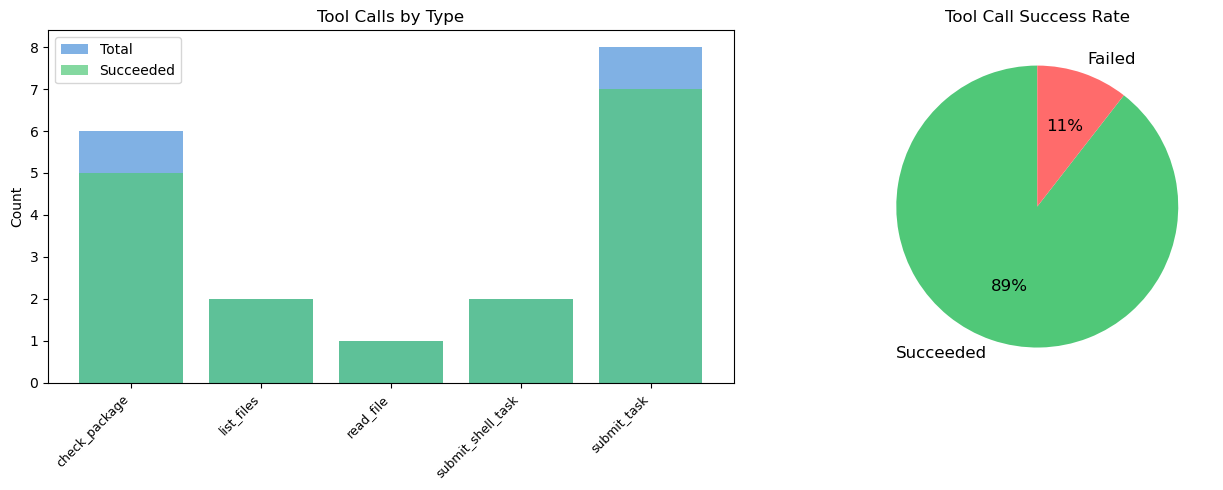

Saved: tool_calls_summary.png


In [46]:
if trace_data:
    tool_calls = [e for e in trace_data['trace'] if e['type'] == 'tool_call']
    
    # Count by tool name
    from collections import Counter
    tool_counts = Counter(tc['tool'] for tc in tool_calls)
    tool_success = Counter(tc['tool'] for tc in tool_calls if tc.get('succeeded'))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart of tool calls
    tools = sorted(tool_counts.keys())
    counts = [tool_counts[t] for t in tools]
    successes = [tool_success.get(t, 0) for t in tools]
    
    x = range(len(tools))
    ax1.bar(x, counts, color='#4A90D9', alpha=0.7, label='Total')
    ax1.bar(x, successes, color='#50C878', alpha=0.7, label='Succeeded')
    ax1.set_xticks(x)
    ax1.set_xticklabels(tools, rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('Count')
    ax1.set_title('Tool Calls by Type')
    ax1.legend()
    
    # Pie chart of success/failure
    total_success = sum(1 for tc in tool_calls if tc.get('succeeded'))
    total_fail = len(tool_calls) - total_success
    ax2.pie([total_success, total_fail],
            labels=['Succeeded', 'Failed'],
            colors=['#50C878', '#FF6B6B'],
            autopct='%1.0f%%', startangle=90, textprops={'fontsize': 12})
    ax2.set_title('Tool Call Success Rate')
    
    plt.tight_layout()
    plt.savefig('tool_calls_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: tool_calls_summary.png")

## 8b. Workflow Waterfall

A trace-style waterfall (like a LangSmith span view) built entirely from the local
trace: the outlined bar is the single agent's invocation (annotated with token usage
when present) -- one continuous span across all three phases, since there's no
separate agent to hand off to. Indented bars are individual tool calls from the
execution phase — green succeeded, red failed. Self-contained and reproducible; no
external service required.

In [ ]:
if trace_data:
    events = trace_data["trace"]
    agent_colors = {
        "single_agent": "#4A90D9",
    }

    # Tokens per agent (to annotate the agent bars), if the trace recorded them
    tokens_by_agent = trace_data.get("summary", {}).get("tokens_by_agent", {})

    # --- Build spans: each becomes one waterfall bar ---
    spans = []  # {label, start, end, color, kind}

    # 1) Agent invocations: real spans from agent_start -> agent_end
    open_starts = {}
    agent_start = None
    for e in events:
        t = e.get("elapsed_s", 0)
        if e["type"] == "agent_start":
            open_starts.setdefault(e["agent"], []).append(t)
            if e["agent"] == "single_agent" and agent_start is None:
                agent_start = t
        elif e["type"] == "agent_end":
            stack = open_starts.get(e["agent"], [])
            start = stack.pop(0) if stack else t
            tok = tokens_by_agent.get(e["agent"])
            label = e["agent"] + (f"  [{tok:,} tok]" if tok else "")
            spans.append({"label": label, "start": start, "end": t,
                          "color": agent_colors.get(e["agent"], "#888888"), "kind": "agent"})

    # 2) Tool calls: duration_s is often 0 in the trace, so estimate each tool's
    #    wall time as the gap since the previous tool finished (first uses agent start).
    prev_t = agent_start
    for e in events:
        if e["type"] != "tool_call":
            continue
        t = e.get("elapsed_s", 0)
        dur = e.get("duration_s", 0)
        start = (t - dur) if dur and dur > 0 else (prev_t if prev_t is not None else t)
        spans.append({"label": "  └ " + e["tool"], "start": start, "end": t,
                      "color": "#2E8B57" if e.get("succeeded") else "#C0392B", "kind": "tool"})
        prev_t = t

    # Order top-down by start time (agents before their tools when tied)
    spans.sort(key=lambda s: (s["start"], s["kind"] != "agent"))

    fig, ax = plt.subplots(figsize=(14, max(4, 0.42 * len(spans))))
    total = max((s["end"] for s in spans), default=1)
    for i, s in enumerate(spans):
        width = max(s["end"] - s["start"], total * 0.004)  # min width so slivers stay visible
        ax.barh(i, width, left=s["start"], color=s["color"], alpha=0.85, height=0.62,
                edgecolor="black" if s["kind"] == "agent" else "none",
                linewidth=0.8 if s["kind"] == "agent" else 0)
        ax.text(s["end"] + total * 0.005, i,
                f'{s["label"]} ({s["end"] - s["start"]:.1f}s)', va="center", fontsize=8)

    ax.set_yticks([])
    ax.invert_yaxis()                       # first event on top, like a trace waterfall
    ax.set_xlim(0, total * 1.28)
    ax.set_xlabel("Elapsed time (s)", fontsize=12)
    ax.set_title("Workflow Waterfall — single agent (outlined) + tool calls (indented)\n"
                 "green = tool succeeded, red = tool failed", fontsize=13)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig("workflow_waterfall.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: workflow_waterfall.png")
else:
    print("No trace_data. Run cell 9 first.")


## 9. Output Files

Check what the workflow produced.

In [47]:
import glob

output_dir = 'work/run0'
if os.path.isdir(output_dir):
    print(f"Output files in {output_dir}/:\n")
    
    # Find key output files
    for ext in ['*.png', '*.gif', '*.csv', '*.py', '*.sh']:
        files = glob.glob(os.path.join(output_dir, '**', ext), recursive=True)
        if files:
            print(f"  {ext}:")
            for f in sorted(files)[:10]:
                size = os.path.getsize(f)
                print(f"    {os.path.relpath(f, output_dir):50s} {size:>10,} bytes")
            if len(files) > 10:
                print(f"    ... and {len(files) - 10} more")
else:
    print("No output directory found. Run the workflow first.")

Output files in work/run0/:

  *.png:
    plots/analytics_timing_comparison.png                  65,541 bytes
    plots/bandwidth_comparison.png                         66,423 bytes
    plots/explained_variance_comparison.png                54,318 bytes
    plots/heat2d_evolution.png                            134,044 bytes
    renders/final_composition.png                          97,281 bytes
    renders/frame_0000.png                                267,660 bytes
    renders/frame_0001 2.png                              305,407 bytes
    renders/frame_0001.png                                265,160 bytes
    renders/frame_0002.png                                264,912 bytes
    renders/frame_0003 2.png                              304,436 bytes
    ... and 141 more
  *.gif:
    renders/animation 2.gif                            12,113,362 bytes
    renders/animation.gif                               5,284,871 bytes
    renders/nucleation_animation.gif                    7,140,452 by

## 10. Display Generated Visualizations

Show the images produced by the workflow.

Found 7 key images:

--- plots/analytics_timing_comparison.png ---


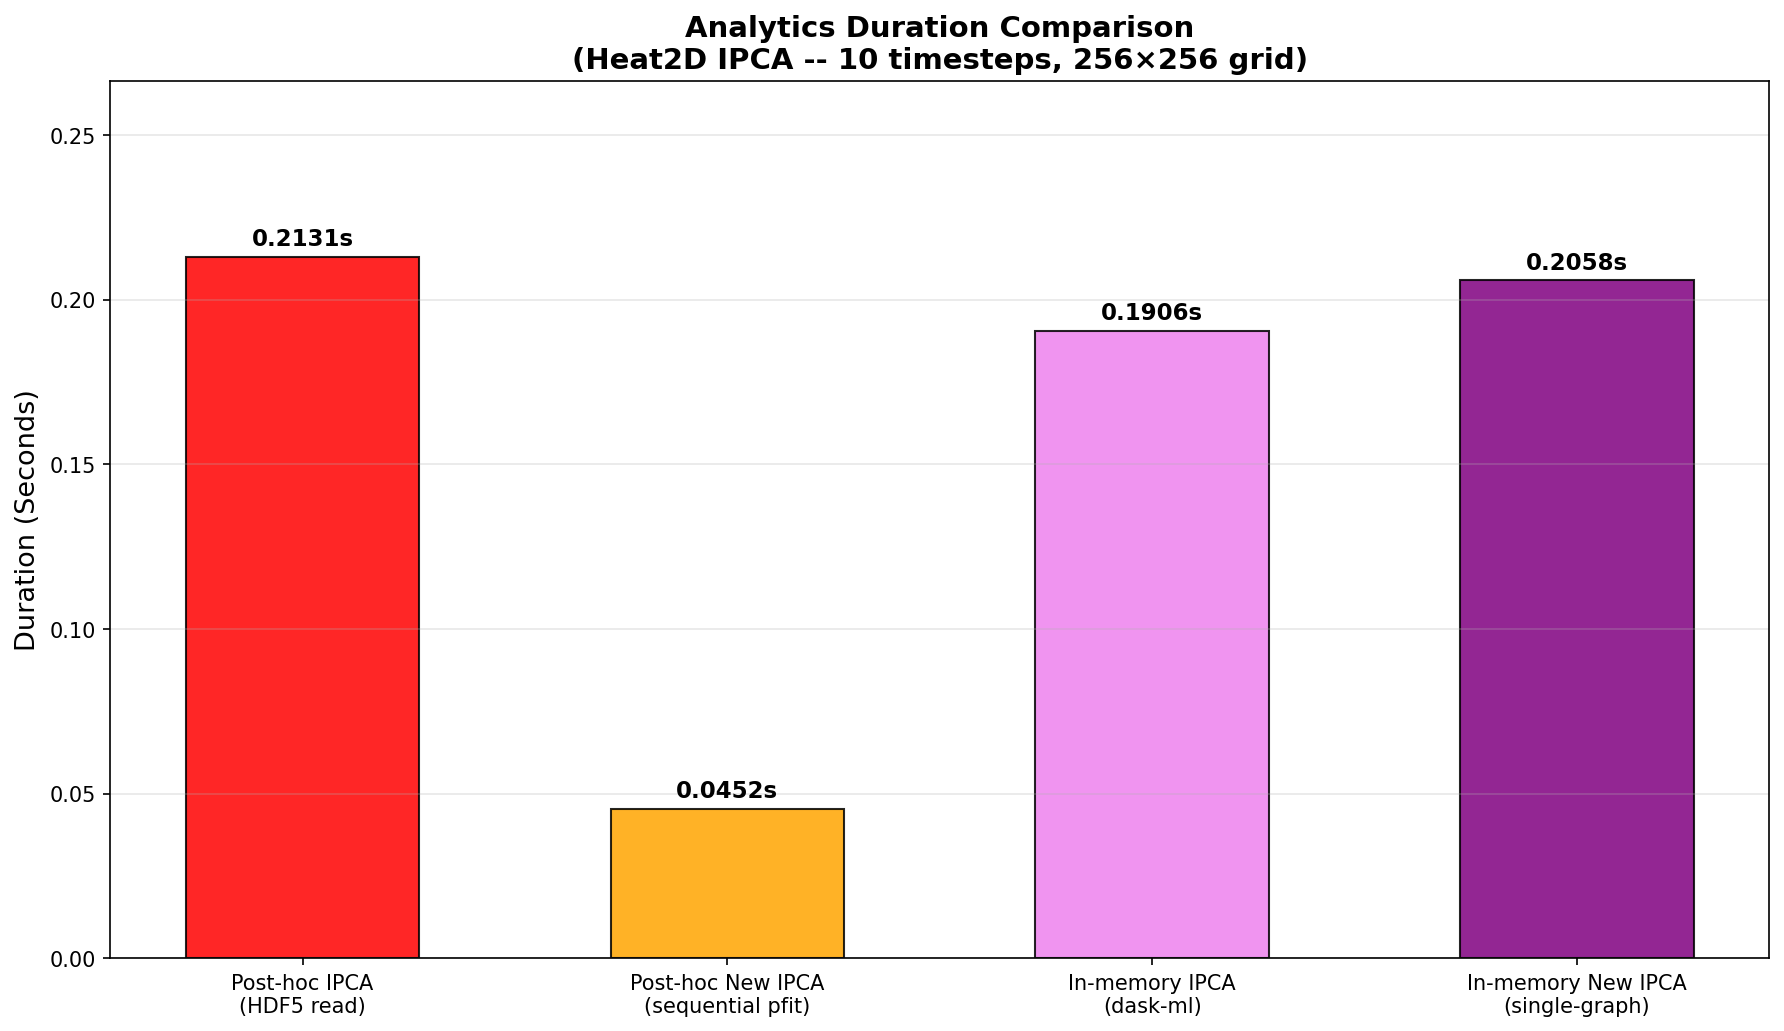

--- plots/bandwidth_comparison.png ---


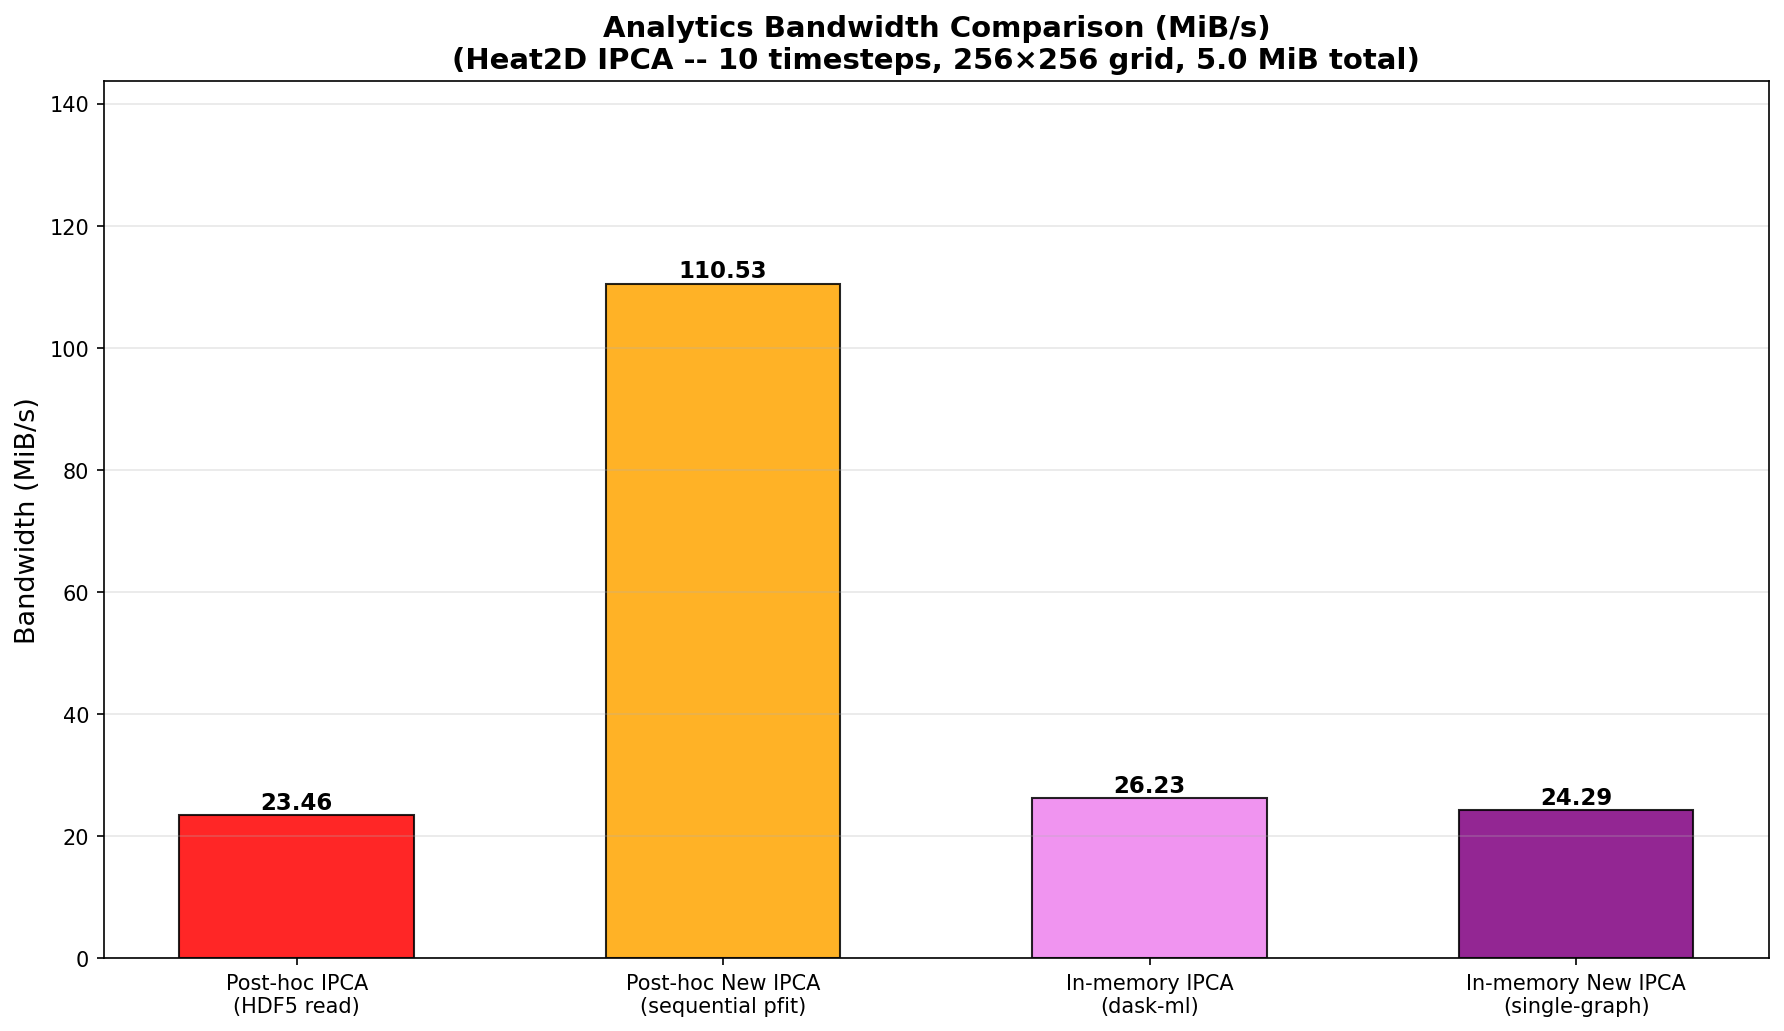

--- plots/explained_variance_comparison.png ---


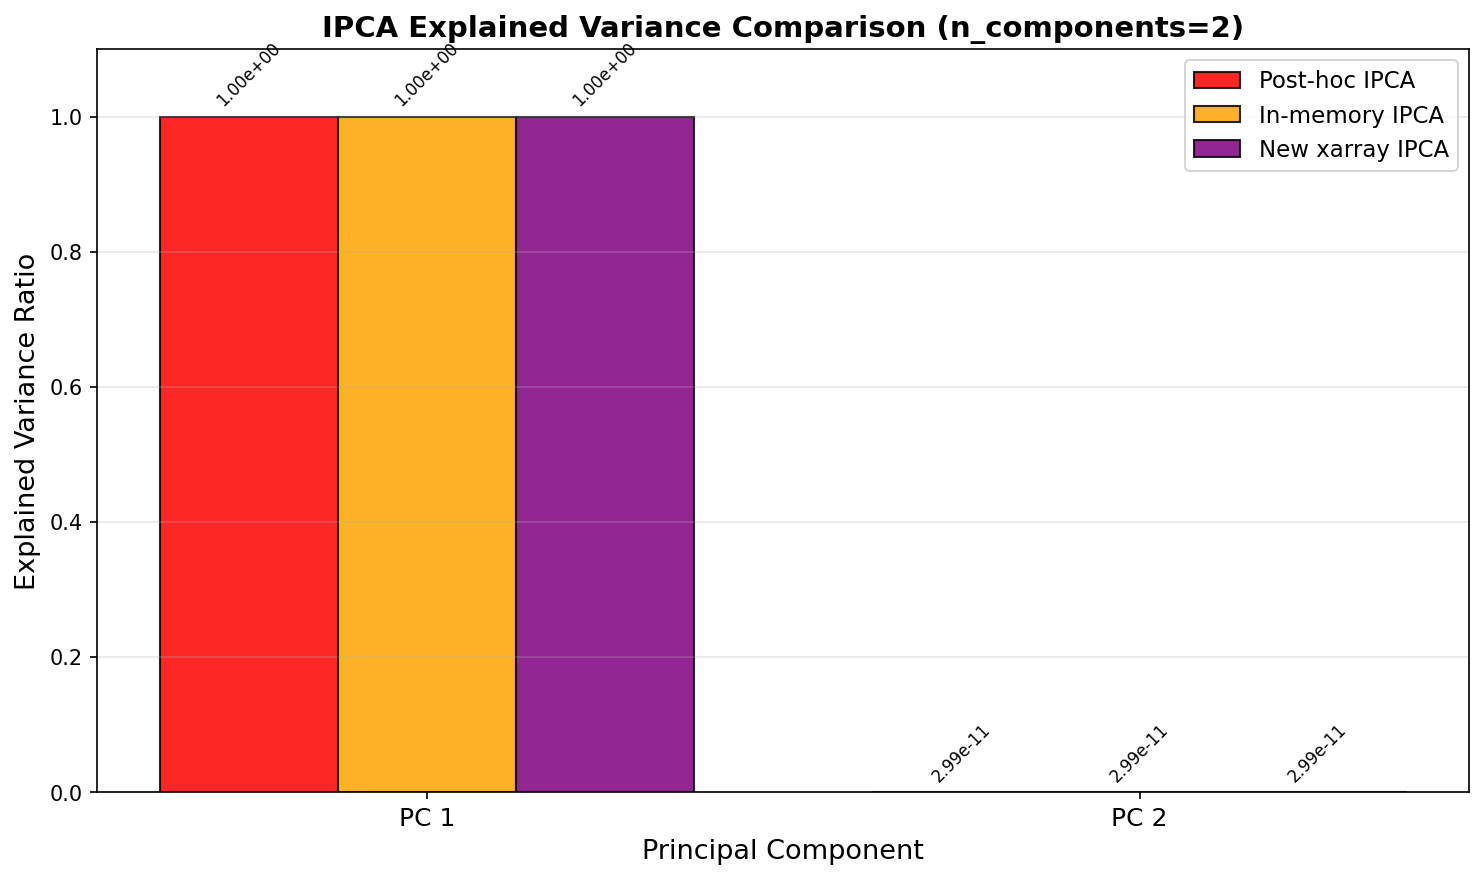

--- plots/heat2d_evolution.png ---


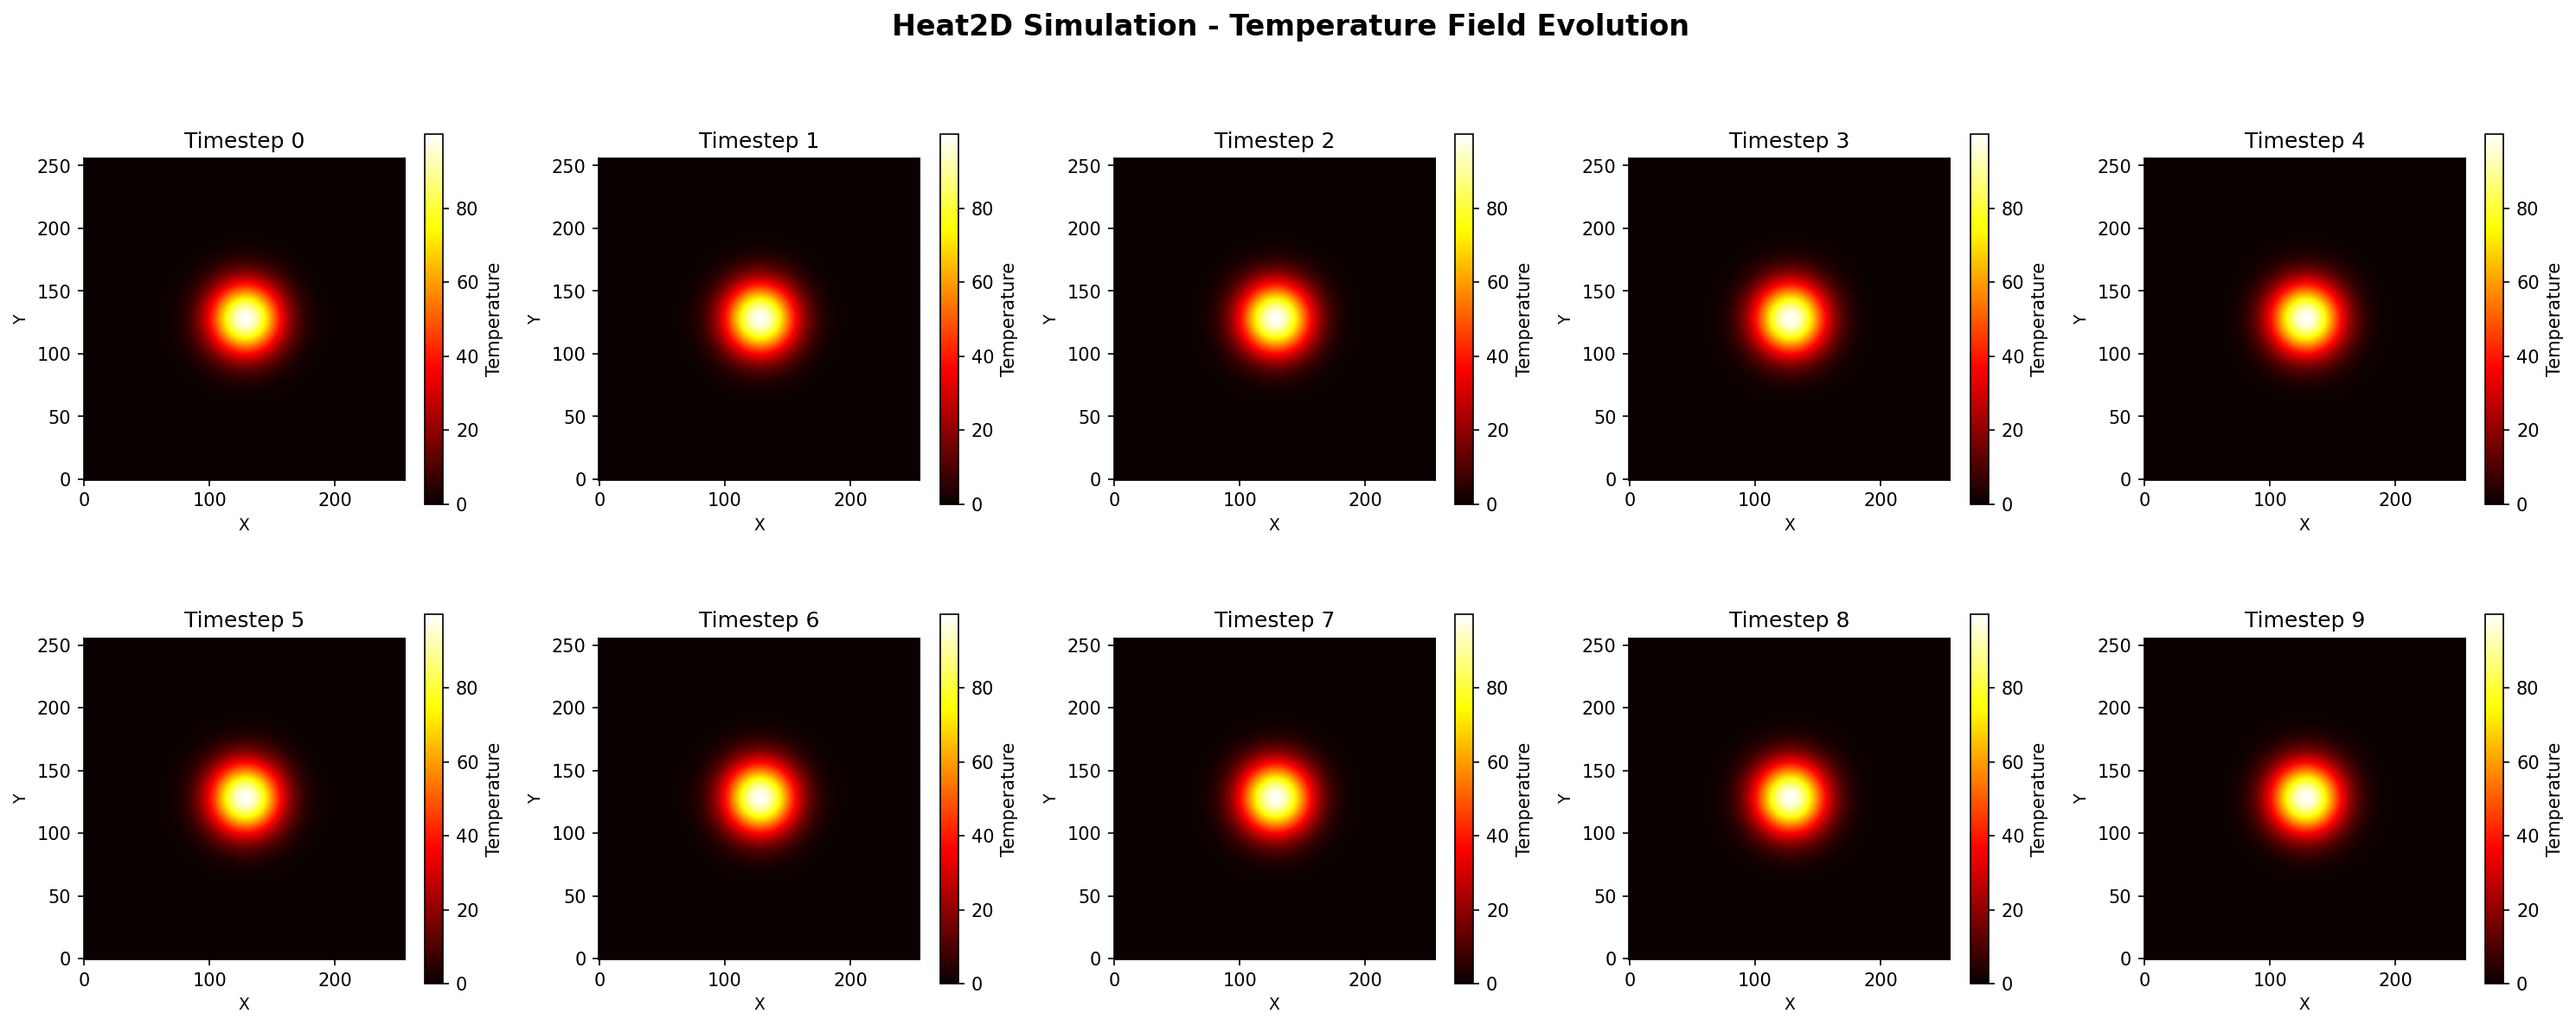

--- renders/final_composition.png ---


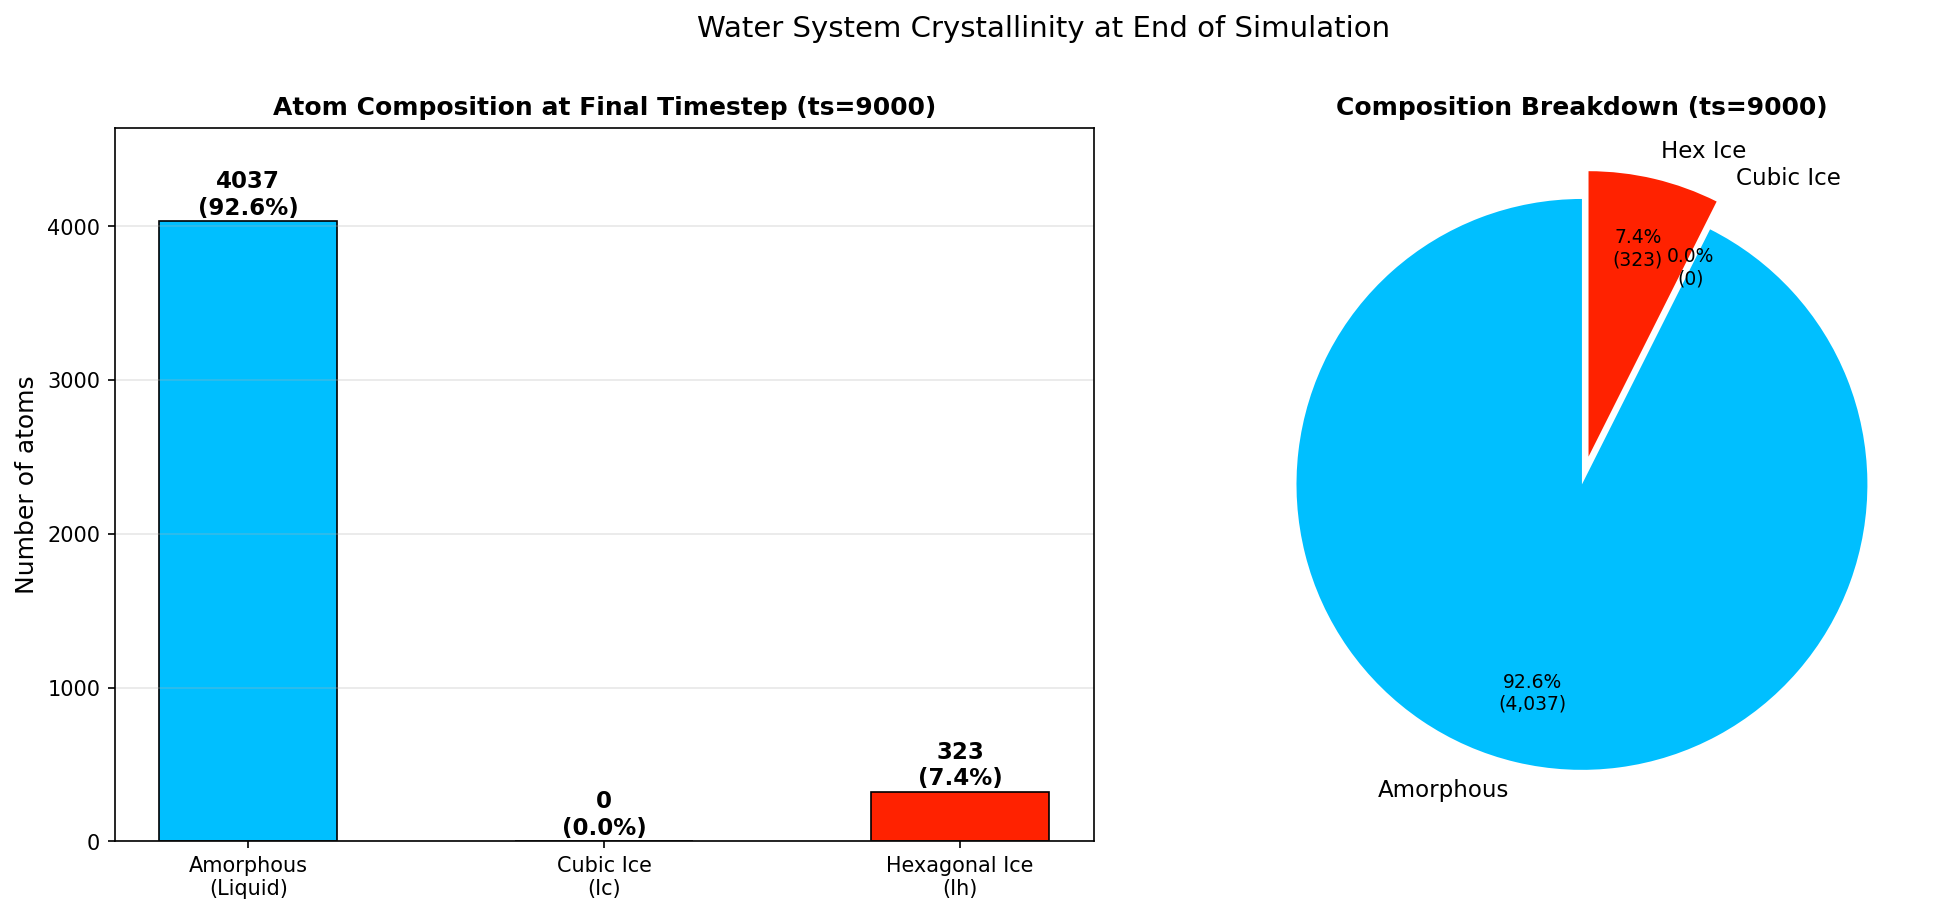

--- renders/nucleation_timeseries.png ---


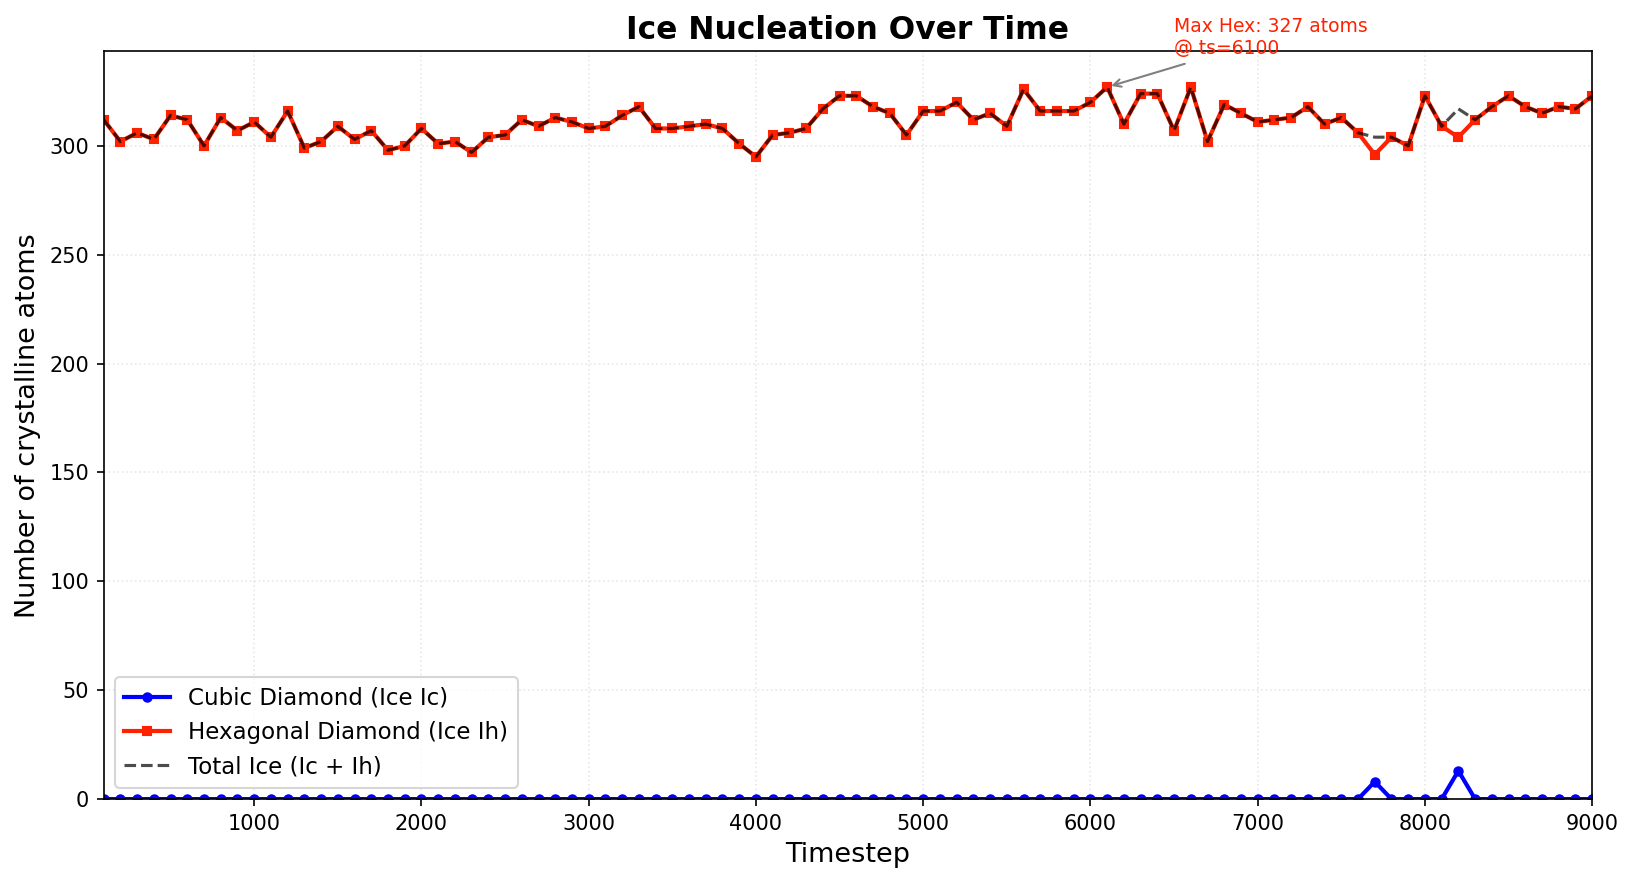

In [48]:
import glob
from IPython.display import display, Image as IPImage

output_dir = 'work/run0'
png_files = sorted(glob.glob(os.path.join(output_dir, '**', '*.png'), recursive=True))

# Filter to key images (not individual frames)
key_images = [f for f in png_files if 'frame_' not in os.path.basename(f)]

if key_images:
    print(f"Found {len(key_images)} key images:\n")
    for img_path in key_images[:6]:
        print(f"--- {os.path.relpath(img_path, output_dir)} ---")
        try:
            display(IPImage(filename=img_path, width=600))
        except Exception as e:
            print(f"  (Could not display: {e})")
else:
    print("No images found. Run the workflow first.")